In [18]:
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mutual_info_score

%matplotlib inline

In [2]:
!wget https://raw.githubusercontent.com/alexeygrigorev/datasets/master/course_lead_scoring.csv

--2025-10-16 09:31:02--  https://raw.githubusercontent.com/alexeygrigorev/datasets/master/course_lead_scoring.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 80876 (79K) [text/plain]
Saving to: ‘course_lead_scoring.csv.1’

course_lead_scoring 100%[===================>]  78.98K  --.-KB/s    in 0.002s  

2025-10-16 09:31:02 (36.5 MB/s) - ‘course_lead_scoring.csv.1’ saved [80876/80876]



In [3]:
df = pd.read_csv('course_lead_scoring.csv')

In [4]:
df.head()

,lead_source,industry,number_of_courses_viewed,annual_income,employment_status,location,interaction_count,lead_score,converted
0,paid_ads,NaN,1,79450.0,unemployed,south_america,4,0.94,1
1,social_media,retail,1,46992.0,employed,south_america,1,0.80,0
2,events,healthcare,5,78796.0,unemployed,australia,3,0.69,1
3,paid_ads,retail,2,83843.0,NaN,australia,1,0.87,0
4,referral,education,3,85012.0,self_employed,europe,3,0.62,1


In [5]:
df.isnull().sum()

lead_source                 128
industry                    134
number_of_courses_viewed      0
annual_income               181
employment_status           100
location                     63
interaction_count             0
lead_score                    0
converted                     0
dtype: int64

In [6]:
df.dtypes

lead_source                  object
industry                     object
number_of_courses_viewed      int64
annual_income               float64
employment_status            object
location                     object
interaction_count             int64
lead_score                  float64
converted                     int64
dtype: object

In [7]:
categorical_fill = ['lead_source', 'industry', 'employment_status', 'location']
numerical_fill = ['annual_income']

In [8]:
df[categorical_fill] = df[categorical_fill].fillna('NA')
df[numerical_fill] = df[numerical_fill].fillna(0)

In [9]:
df.isnull().sum()

lead_source                 0
industry                    0
number_of_courses_viewed    0
annual_income               0
employment_status           0
location                    0
interaction_count           0
lead_score                  0
converted                   0
dtype: int64

In [10]:
df['industry'].value_counts()

industry
retail           203
finance          200
other            198
healthcare       187
education        187
technology       179
manufacturing    174
NA               134
Name: count, dtype: int64

In [11]:
df.industry.mode()

0    retail
Name: industry, dtype: object

In [12]:
corr_matrix = df.select_dtypes(include=['number']).corr()
corr_matrix


,number_of_courses_viewed,annual_income,interaction_count,lead_score,converted
number_of_courses_viewed,1.000000,0.009770,-0.023565,-0.004879,0.435914
annual_income,0.009770,1.000000,0.027036,0.015610,0.053131
interaction_count,-0.023565,0.027036,1.000000,0.009888,0.374573
lead_score,-0.004879,0.015610,0.009888,1.000000,0.193673
converted,0.435914,0.053131,0.374573,0.193673,1.000000


In [13]:
interaction_count_lead_score = corr_matrix.loc['interaction_count', 'lead_score']
number_of_courses_viewed_lead_score = corr_matrix.loc['number_of_courses_viewed', 'lead_score']
number_of_courses_viewed_interaction_count = corr_matrix.loc['number_of_courses_viewed', 'interaction_count']
annual_income_interaction_count = corr_matrix.loc['annual_income', 'interaction_count']

In [14]:
print("interaction_count and lead_score correlation:", interaction_count_lead_score)
print("number_of_courses_viewed and lead_score correlation:", number_of_courses_viewed_lead_score)
print("number_of_courses_viewed and interaction_count correlation:", number_of_courses_viewed_interaction_count)
print("annual_income and interaction_count correlation:", annual_income_interaction_count)

interaction_count and lead_score correlation: 0.009888182496913131
number_of_courses_viewed and lead_score correlation: -0.004878998354681276
number_of_courses_viewed and interaction_count correlation: -0.023565222882888037
annual_income and interaction_count correlation: 0.02703647240481443


<Axes: >

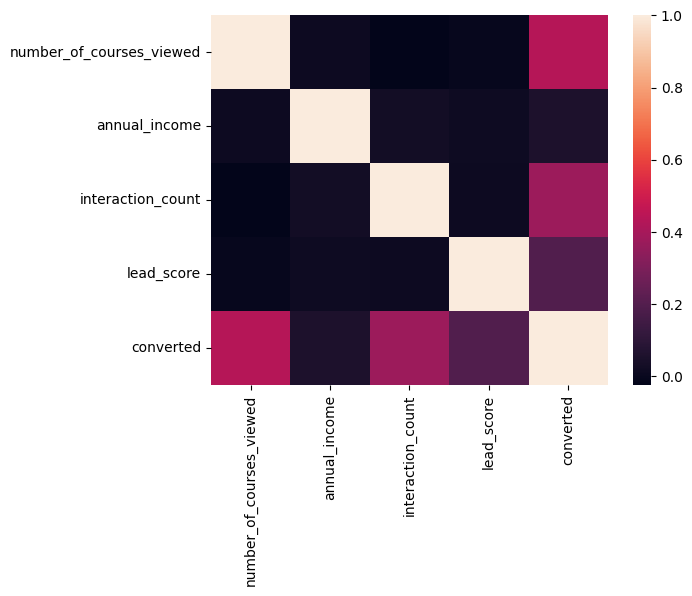

In [15]:
sns.heatmap(corr_matrix)

In [31]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=42)
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [33]:
y_train = df_train.converted.values
y_val = df_val.converted.values
y_test = df_test.converted.values

del df_train['converted']
del df_val['converted']
del df_test['converted']


In [32]:
df_train

,lead_source,industry,number_of_courses_viewed,annual_income,employment_status,location,interaction_count,lead_score,converted
0,NA,NA,2,37512.0,student,middle_east,3,0.04,0
1,organic_search,finance,4,37196.0,unemployed,middle_east,7,0.07,1
2,organic_search,technology,1,50625.0,unemployed,north_america,4,0.49,0
3,organic_search,education,0,68182.0,employed,south_america,4,0.55,1
4,paid_ads,education,1,67902.0,employed,africa,3,0.70,1
...,...,...,...,...,...,...,...,...,...
871,organic_search,finance,1,48622.0,employed,north_america,3,0.32,0
872,events,healthcare,0,65823.0,employed,south_america,3,0.94,0
873,paid_ads,retail,4,49204.0,self_employed,australia,3,0.70,1
874,referral,technology,2,64953.0,unemployed,africa,1,0.90,0


In [34]:
def apply_mutual_score(value):
    return mutual_info_score(value, df_full_train.converted)

In [35]:
categorical_mi = ['industry', 'location', 'lead_source', 'employment_status']
mi = df_full_train[categorical_mi].apply(apply_mutual_score)
mi

industry             0.008173
location             0.001212
lead_source          0.024562
employment_status    0.012690
dtype: float64

In [36]:
model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000, random_state=42)

In [37]:
df_train_dummies = pd.get_dummies(df_train.copy(), drop_first=False)
df_val_dummies = pd.get_dummies(df_val.copy(), drop_first=False)

df_val_dummies = df_val_dummies.reindex(columns=df_train_dummies.columns, fill_value=0)

In [38]:
model.fit(df_train_dummies, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'liblinear'
,max_iter,1000
,multi_class,'deprecated'


In [40]:
y_predict = model.predict_proba(df_val_dummies)[:,1]
y_predict

array([0.57227288, 0.94745409, 0.705476  , 0.36703491, 0.41843683,
       0.85216429, 0.74715483, 0.48290652, 0.75524254, 0.71279964,
       0.59322595, 0.3375952 , 0.5341181 , 0.64808255, 0.62082965,
       0.51623625, 0.80662949, 0.77277897, 0.65041442, 0.54989428,
       0.87647019, 0.58499546, 0.40498535, 0.63591779, 0.63969166,
       0.441542  , 0.44530037, 0.34513302, 0.72545819, 0.72710924,
       0.29985713, 0.67092115, 0.8277596 , 0.96026939, 0.93617136,
       0.93614277, 0.50585187, 0.61374534, 0.64187573, 0.71478765,
       0.90720746, 0.48707569, 0.83906217, 0.60039127, 0.6271834 ,
       0.5999598 , 0.73491763, 0.52526541, 0.53386416, 0.74145663,
       0.48993084, 0.89800315, 0.93726341, 0.90796424, 0.61662668,
       0.43590645, 0.40082827, 0.58189024, 0.36182863, 0.45664029,
       0.87246611, 0.80956876, 0.65843905, 0.68365322, 0.80904658,
       0.57407686, 0.84363358, 0.52784898, 0.77822453, 0.70639166,
       0.60520582, 0.72713823, 0.42002469, 0.82684972, 0.71476

In [42]:
churn_decision = (y_predict >= 0.5)
churn_decision

array([ True,  True,  True, False, False,  True,  True, False,  True,
        True,  True, False,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True, False,  True,  True, False, False,
       False,  True,  True, False,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True, False,  True,  True,  True,
        True,  True,  True,  True,  True, False,  True,  True,  True,
        True, False, False,  True, False, False,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
       False,  True,  True,  True,  True,  True,  True,  True,  True,
       False,  True, False,  True,  True,  True,  True,  True,  True,
        True,  True, False,  True,  True,  True, False,  True,  True,
       False,  True,  True,  True, False,  True,  True,  True, False,
        True,  True, False, False,  True, False,  True,  True,  True,
        True,  True,  True,  True, False,  True,  True,  True,  True,
        True,  True,

In [44]:
percent_correct_predictions = (churn_decision == y_val).mean()

In [45]:
y_val = np.array(y_val)
original_accuracy = (y_val == churn_decision).mean()
rounded_accuracy = round(original_accuracy,2)
rounded_accuracy

np.float64(0.73)

In [ ]:
features = list(df_train.columns)

for feature in features:
    copy = features.copy()
    copy.remove(feature)
    
    train_dict = data_train[copy].to_dict(orient= 'records')
    X_train = dv.fit_transform(train_dict)

    val_dict = data_val[copy].to_dict(orient = 'records')
    X_val = dv.fit_transform(val_dict)
    
    model = LogisticRegression(solver='liblinear', C=1.0, random_state=42)
    model.fit(X_train, y_train)
    
    y_pred = model.predict_proba(X_val)[:, 1]
    
    above_average_decision = (y_pred >= 0.5)
    
    y_val = np.array(y_val)
    accuracy = str(abs((y_val == above_average_decision).mean() - original_accuracy))
    
    print('For the model without the feature ' + feature + ': the difference in accuracy  is: ' + accuracy)

In [56]:
from sklearn.feature_extraction import DictVectorizer
dv = DictVectorizer(sparse = False)


features = list(df_train.columns)
for feature in features:
    copy = features.copy()
    copy.remove(feature)

    train_dict = df_train[copy].to_dict(orient= 'records')
    X_train = dv.fit_transform(train_dict)
    val_dict = df_val[copy].to_dict(orient = 'records')
    X_val = dv.fit_transform(val_dict)
    model = LogisticRegression(solver='liblinear', C=1.0, random_state=42)
    model.fit(X_train, y_train)

    y_pred = model.predict_proba(X_val)[:, 1]

    above_average_decision = (y_pred >= 0.5)

    y_val = np.array(y_val)
    accuracy = str(abs((y_val == above_average_decision).mean() - original_accuracy))
    
    print('For the model without the feature ' + feature + ': the difference in accuracy  is: ' + accuracy)

For the model without the feature lead_source: the difference in accuracy  is: 0.010238907849829393
For the model without the feature industry: the difference in accuracy  is: 0.010238907849829393
For the model without the feature number_of_courses_viewed: the difference in accuracy  is: 0.10921501706484638
For the model without the feature annual_income: the difference in accuracy  is: 0.09556313993174059
For the model without the feature employment_status: the difference in accuracy  is: 0.0
For the model without the feature location: the difference in accuracy  is: 0.0
For the model without the feature interaction_count: the difference in accuracy  is: 0.04778156996587024
For the model without the feature lead_score: the difference in accuracy  is: 0.0


In [58]:
import sklearn.metrics as skm 


df_train_c001 = df_train.copy(deep=True)
df_val_c001   = df_val.copy(deep=True)
X_train_c001  = pd.get_dummies(df_train_c001, drop_first=False)
X_val_c001    = pd.get_dummies(df_val_c001, drop_first=False).reindex(columns=X_train_c001.columns, fill_value=0)

# --- Dataset 2 ---
df_train_c01 = df_train.copy(deep=True)
df_val_c01   = df_val.copy(deep=True)
X_train_c01  = pd.get_dummies(df_train_c01, drop_first=False)
X_val_c01    = pd.get_dummies(df_val_c01, drop_first=False).reindex(columns=X_train_c01.columns, fill_value=0)

# --- Dataset 3 ---
df_train_c1 = df_train.copy(deep=True)
df_val_c1   = df_val.copy(deep=True)
X_train_c1  = pd.get_dummies(df_train_c1, drop_first=False)
X_val_c1    = pd.get_dummies(df_val_c1, drop_first=False).reindex(columns=X_train_c1.columns, fill_value=0)

# --- Dataset 4 ---
df_train_c10 = df_train.copy(deep=True)
df_val_c10   = df_val.copy(deep=True)
X_train_c10  = pd.get_dummies(df_train_c10, drop_first=False)
X_val_c10    = pd.get_dummies(df_val_c10, drop_first=False).reindex(columns=X_train_c10.columns, fill_value=0)

# --- Dataset 5 ---
df_train_c100 = df_train.copy(deep=True)
df_val_c100   = df_val.copy(deep=True)
X_train_c100  = pd.get_dummies(df_train_c100, drop_first=False)
X_val_c100    = pd.get_dummies(df_val_c100, drop_first=False).reindex(columns=X_train_c100.columns, fill_value=0)

# --- Train models ---
model_c001 = LogisticRegression(solver='liblinear', C=0.01, max_iter=1000, random_state=42)
model_c001.fit(X_train_c001, y_train)
acc_c001 = skm.accuracy_score(y_val, (model_c001.predict_proba(X_val_c001)[:,1] >= 0.5))

model_c01 = LogisticRegression(solver='liblinear', C=0.1, max_iter=1000, random_state=42)
model_c01.fit(X_train_c01, y_train)
acc_c01 = skm.accuracy_score(y_val, (model_c01.predict_proba(X_val_c01)[:,1] >= 0.5))

model_c1 = LogisticRegression(solver='liblinear', C=1, max_iter=1000, random_state=42)
model_c1.fit(X_train_c1, y_train)
acc_c1 = skm.accuracy_score(y_val, (model_c1.predict_proba(X_val_c1)[:,1] >= 0.5))

model_c10 = LogisticRegression(solver='liblinear', C=10, max_iter=1000, random_state=42)
model_c10.fit(X_train_c10, y_train)
acc_c10 = skm.accuracy_score(y_val, (model_c10.predict_proba(X_val_c10)[:,1] >= 0.5))

model_c100 = LogisticRegression(solver='liblinear', C=100, max_iter=1000, random_state=42)
model_c100.fit(X_train_c100, y_train)
acc_c100 = skm.accuracy_score(y_val, (model_c100.predict_proba(X_val_c100)[:,1] >= 0.5))

# --- Collect results ---
models = {
    0.01: model_c001,
    0.1:  model_c01,
    1:    model_c1,
    10:   model_c10,
    100:  model_c100
}

accuracies = {
    0.01: acc_c001,
    0.1:  acc_c01,
    1:    acc_c1,
    10:   acc_c10,
    100:  acc_c100
}

# --- Print summary ---
for c in [0.01, 0.1, 1, 10, 100]:
    print(f"C={c}: Accuracy={accuracies[c]:.10f}")

best_c = max(accuracies, key=accuracies.get)
print(f"Best model C={best_c} with accuracy {accuracies[best_c]:.10f}")

C=0.01: Accuracy=0.7303754266
C=0.1: Accuracy=0.7303754266
C=1: Accuracy=0.7303754266
C=10: Accuracy=0.7303754266
C=100: Accuracy=0.7303754266
Best model C=0.01 with accuracy 0.7303754266
